## 1. Setup

In [41]:
import time, random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.float_format", "{:.3f}".format)

# ── import game modules ──────────────────────────────────────────────────────
from config import PLAYER_W, PLAYER_B, ALGO_MINIMAX, ALGO_ALPHABETA
from board import make_initial_board
from game import apply_move, check_winner
import algorithms

HEURISTIC_SHORT = {
    0: "H0 – piece count",
    1: "H1 – advancement",
    2: "H2 – mobility",
    3: "H3 – capture potential",
    4: "H4 – passed pieces",
    5: "H5 – combined",
}

# ── single-game runner with fixed heuristic for testing and data collection ───────────────────────────────────────────────────────
def run_game(rows: int, cols: int, depth: int,
             algorithm: str, heuristic_id: int,
             max_rounds: int = 200, seed: int = 0) -> dict:
    """Run one complete game and return summary statistics."""
    random.seed(seed)
    board   = make_initial_board(rows, cols)
    current = PLAYER_W
    rounds  = 0
    winner  = None
    algorithms.nodes_visited = 0
    t0 = time.perf_counter()

    while rounds < max_rounds:
        winner = check_winner(board)
        if winner:
            break
        move = algorithms.choose_move(board, current, depth,
                                         heuristic_id, algorithm)
        if move is None:
            winner = PLAYER_B if current == PLAYER_W else PLAYER_W
            break
        board   = apply_move(board, move)
        rounds += 1
        current = PLAYER_B if current == PLAYER_W else PLAYER_W

    elapsed = time.perf_counter() - t0
    winner  = check_winner(board) or winner
    return {
        "rows": rows, "cols": cols, "depth": depth,
        "algorithm": algorithm, "heuristic": heuristic_id,
        "winner": winner,
        "rounds": rounds,
        "nodes": algorithms.nodes_visited,
        "time_s": elapsed,
    }

print("Setup complete.")


Setup complete.


## 2. Data Collection

In [42]:
records = []

# ── Experiment A: depth x heuristic (6×6 board, alpha-beta) ─────────────────
for depth in [1, 2, 3, 4]:
    for h in [0, 1, 2, 3, 4, 5]:
        r = run_game(6, 6, depth, ALGO_ALPHABETA, h)
        r["experiment"] = "A"
        records.append(r)

# ── Experiment B: algorithm comparison at several depths (6×6, H0) ───────────
for depth in [1, 2, 3, 4]:
    for algo in [ALGO_MINIMAX, ALGO_ALPHABETA]:
        r = run_game(6, 6, depth, algo, heuristic_id=0)
        r["experiment"] = "B"
        records.append(r)

# ── Experiment C: board size effect (depth=3, alpha-beta, H5) ────────────────
for rows, cols in [(4, 4), (4, 6), (6, 6), (6, 8), (8, 6), (8, 8)]:
    r = run_game(rows, cols, depth=3, algorithm=ALGO_ALPHABETA, heuristic_id=5)
    r["experiment"] = "C"
    records.append(r)

# ── Experiment D: heuristic head-to-head – W uses H_i, B uses H_j ────────────
# We simulate this by running games where both players are fixed to the same
# heuristic (as in basic mode). For a richer comparison we vary heuristic
# and depth on an 8×8 board with alpha-beta.
for depth in [1, 2]:
    for h in [0, 1, 2, 3, 4, 5]:
        r = run_game(8, 8, depth, ALGO_ALPHABETA, h)
        r["experiment"] = "D"
        records.append(r)

df = pd.DataFrame(records)
df["algo_label"] = df["algorithm"].map({ALGO_MINIMAX: "Minimax", ALGO_ALPHABETA: "α-β"})
df["h_label"]    = df["heuristic"].map(HEURISTIC_SHORT)
df["board"]      = df["rows"].astype(str) + "×" + df["cols"].astype(str)
df["cells"]      = df["rows"] * df["cols"]

print(f"Total games recorded: {len(df)}")
df.head(10)


Total games recorded: 50


,rows,cols,depth,algorithm,heuristic,winner,rounds,nodes,time_s,experiment,algo_label,h_label,board,cells
0,6,6,1,alphabeta,0,B,42,654,0.068,A,α-β,H0 – piece count,6×6,36
1,6,6,1,alphabeta,1,B,42,654,0.053,A,α-β,H1 – advancement,6×6,36
2,6,6,1,alphabeta,2,B,46,833,0.099,A,α-β,H2 – mobility,6×6,36
3,6,6,1,alphabeta,3,W,9,160,0.027,A,α-β,H3 – capture potential,6×6,36
4,6,6,1,alphabeta,4,B,26,558,0.084,A,α-β,H4 – passed pieces,6×6,36
5,6,6,1,alphabeta,5,W,21,364,0.057,A,α-β,H5 – combined,6×6,36
6,6,6,2,alphabeta,0,W,23,1665,0.180,A,α-β,H0 – piece count,6×6,36
7,6,6,2,alphabeta,1,W,23,1849,0.162,A,α-β,H1 – advancement,6×6,36
8,6,6,2,alphabeta,2,B,38,4576,0.564,A,α-β,H2 – mobility,6×6,36
9,6,6,2,alphabeta,3,W,27,3165,0.949,A,α-β,H3 – capture potential,6×6,36


## 3. Experiment A – Depth x Heuristic

6×6 board, alpha-beta pruning. Both players use the same heuristic.

In [52]:
tA = (df[df.experiment == "A"]
      [["depth", "h_label", "winner", "rounds", "nodes", "time_s"]]
      .rename(columns={"h_label": "heuristic", "time_s": "time (s)"}))

tA.index = range(len(tA))
print(tA.to_string(index=False))


 depth              heuristic winner  rounds  nodes  time (s)
     1       H0 – piece count      B      42    654     0.068
     1       H1 – advancement      B      42    654     0.053
     1          H2 – mobility      B      46    833     0.099
     1 H3 – capture potential      W       9    160     0.027
     1     H4 – passed pieces      B      26    558     0.084
     1          H5 – combined      W      21    364     0.057
     2       H0 – piece count      W      23   1665     0.180
     2       H1 – advancement      W      23   1849     0.162
     2          H2 – mobility      B      38   4576     0.564
     2 H3 – capture potential      W      27   3165     0.949
     2     H4 – passed pieces      W      43   4000     0.596
     2          H5 – combined      B      44   2859     0.284
     3       H0 – piece count      B      36  21819     2.689
     3       H1 – advancement      W      13  10948     1.255
     3          H2 – mobility      W      33  39241     5.427
     3 H

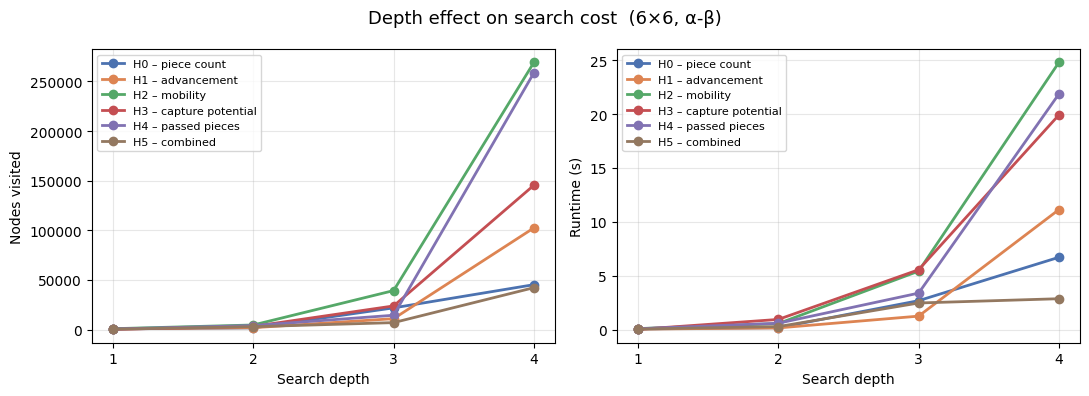

Saved: plots/plot_A_depth_cost.png


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Depth effect on search cost  (6×6, α-β)", fontsize=13)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

for ax, metric, ylabel in zip(
    axes,
    ["nodes", "time_s"],
    ["Nodes visited", "Runtime (s)"],
):
    for i, (h, grp) in enumerate(df[df.experiment == "A"].groupby("heuristic")):
        grp_s = grp.sort_values("depth")
        ax.plot(grp_s["depth"], grp_s[metric],
                marker="o", linewidth=2, color=colors[i],
                label=HEURISTIC_SHORT[h])
    ax.set_xlabel("Search depth")
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2, 3, 4])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/plot_A_depth_cost.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: plots/plot_A_depth_cost.png")


## 4. Experiment B – Minimax vs α-β Pruning

6×6 board, heuristic H0, varying depth. Both algorithms must return the same move — only cost differs.

In [54]:
tB = (df[df.experiment == "B"]
      [["depth", "algo_label", "winner", "rounds", "nodes", "time_s"]]
      .rename(columns={"algo_label": "algorithm", "time_s": "time (s)"}))

tB.index = range(len(tB))
print(tB.to_string(index=False))


 depth algorithm winner  rounds   nodes  time (s)
     1   Minimax      B      42     654     0.046
     1       α-β      B      42     654     0.043
     2   Minimax      W      23    5819     0.533
     2       α-β      W      23    1665     0.151
     3   Minimax      B      36  161131    11.044
     3       α-β      B      36   21819     1.679
     4   Minimax      W      25 2017794   145.447
     4       α-β      W      25   45210     2.948


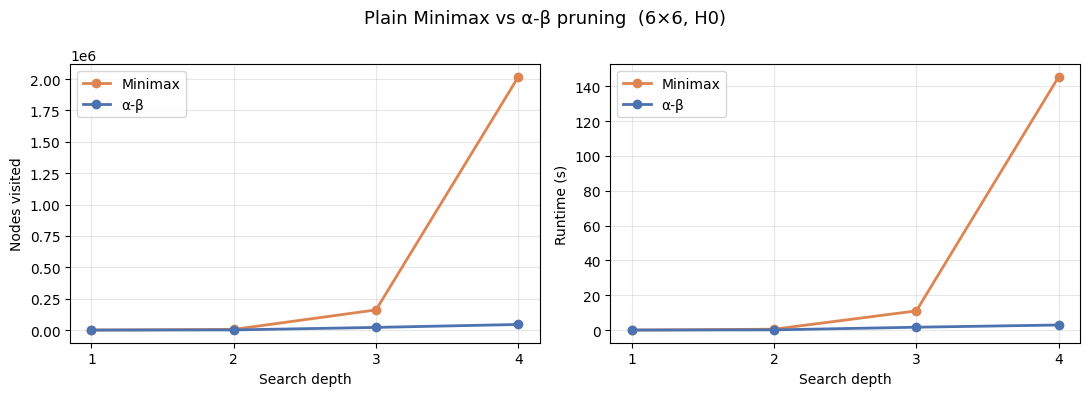

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Plain Minimax vs α-β pruning  (6×6, H0)", fontsize=13)

for ax, metric, ylabel in zip(
    axes,
    ["nodes", "time_s"],
    ["Nodes visited", "Runtime (s)"],
):
    for algo, color, label in [
        (ALGO_MINIMAX,   "#DD8452", "Minimax"),
        (ALGO_ALPHABETA, "#4C72B0", "α-β"),
    ]:
        grp = df[(df.experiment == "B") & (df.algorithm == algo)].sort_values("depth")
        ax.plot(grp["depth"], grp[metric],
                marker="o", linewidth=2, color=color, label=label)

    ax.set_xlabel("Search depth")
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2, 3, 4])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/plot_B_algo_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


In [56]:
mm = df[(df.experiment == "B") & (df.algorithm == ALGO_MINIMAX)].set_index("depth")
ab = df[(df.experiment == "B") & (df.algorithm == ALGO_ALPHABETA)].set_index("depth")

speedup = pd.DataFrame({
    "depth":          mm.index,
    "nodes (Minimax)": mm["nodes"].values,
    "nodes (α-β)":     ab["nodes"].values,
    "node reduction %": ((1 - ab["nodes"] / mm["nodes"]) * 100).round(1).values,
    "speedup ×":       (mm["time_s"] / ab["time_s"]).round(2).values,
})
print(speedup.to_string(index=False))


 depth  nodes (Minimax)  nodes (α-β)  node reduction %  speedup ×
     1              654          654             0.000      1.050
     2             5819         1665            71.400      3.540
     3           161131        21819            86.500      6.580
     4          2017794        45210            97.800     49.330


## 5. Experiment C – Board Size Effect

Depth = 2, α-β, heuristic H2. Rows and columns varied independently to show the effect of each dimension.

In [57]:
tC = (df[df.experiment == "C"]
      [["board", "cells", "winner", "rounds", "nodes", "time_s"]]
      .rename(columns={"time_s": "time (s)"}))

tC.index = range(len(tC))
print(tC.to_string(index=False))


board  cells winner  rounds  nodes  time (s)
  4×4     16      B      12   1197     0.034
  4×6     24      B      16   4189     0.239
  6×6     36      W      17   6962     0.534
  6×8     48      W      17  12368     1.325
  8×6     48      B      52  30088     2.552
  8×8     64      B      68  93467    10.259


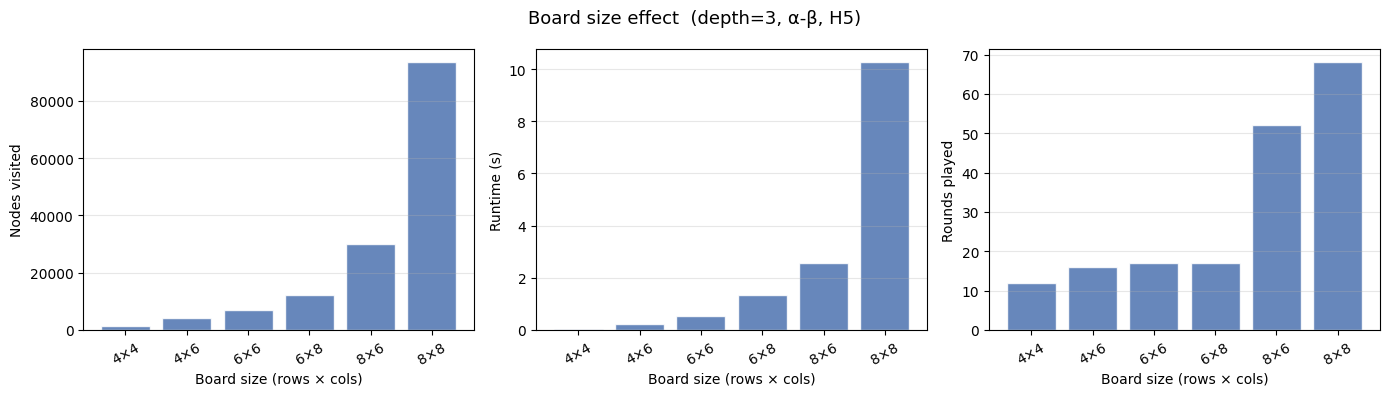

In [58]:
grpC = df[df.experiment == "C"].sort_values("cells")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Board size effect  (depth=3, α-β, H5)", fontsize=13)

for ax, metric, ylabel in zip(
    axes,
    ["nodes", "time_s", "rounds"],
    ["Nodes visited", "Runtime (s)", "Rounds played"],
):
    ax.bar(grpC["board"], grpC[metric], color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.set_xlabel("Board size (rows × cols)")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plots/plot_C_board_size.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Experiment D – Heuristic Comparison on 8×8 Board

8×8 board, α-β, depths 1 and 2.

In [59]:
tD = (df[df.experiment == "D"]
      [["depth", "h_label", "winner", "rounds", "nodes", "time_s"]]
      .rename(columns={"h_label": "heuristic", "time_s": "time (s)"}))

tD.index = range(len(tD))
print(tD.to_string(index=False))


 depth              heuristic winner  rounds  nodes  time (s)
     1       H0 – piece count      B      86   1841     0.168
     1       H1 – advancement      B      86   1841     0.163
     1          H2 – mobility      W      87   2709     0.473
     1 H3 – capture potential      W      25    758     0.176
     1     H4 – passed pieces      W      69   2093     0.306
     1          H5 – combined      W      11    259     0.036
     2       H0 – piece count      B      50   8281     0.920
     2       H1 – advancement      B      50   9084     1.006
     2          H2 – mobility      B      68  21016     3.031
     2 H3 – capture potential      W      41  11523     2.491
     2     H4 – passed pieces      W      21   2342     0.262
     2          H5 – combined      B      72   5863     0.513


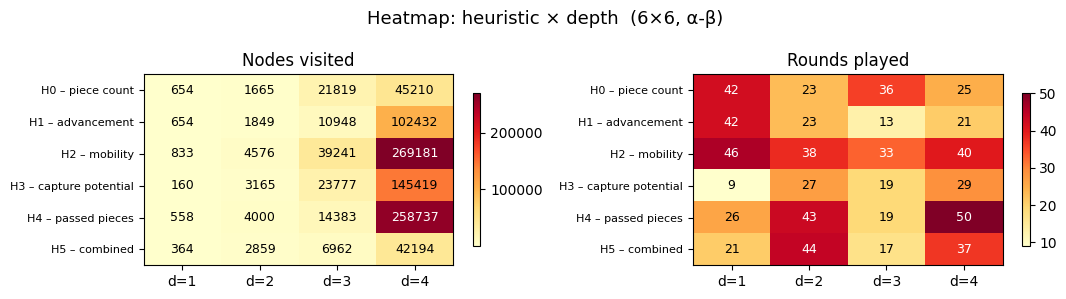

In [60]:
pivot_nodes = (
    df[df.experiment == "A"]
    .pivot(index="heuristic", columns="depth", values="nodes")
    .rename(index=HEURISTIC_SHORT)
)
pivot_rounds = (
    df[df.experiment == "A"]
    .pivot(index="heuristic", columns="depth", values="rounds")
    .rename(index=HEURISTIC_SHORT)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
fig.suptitle("Heatmap: heuristic × depth  (6×6, α-β)", fontsize=13)

for ax, pivot, title in zip(
    axes,
    [pivot_nodes, pivot_rounds],
    ["Nodes visited", "Rounds played"],
):
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f"d={c}" for c in pivot.columns])
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i,j]:.0f}",
                    ha="center", va="center", fontsize=9,
                    color="black" if pivot.values[i,j] < pivot.values.max()*0.6 else "white")

plt.tight_layout()
plt.savefig("plots/plot_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
